Lab 2: Predictive Analytics with Machine Learning
Student Name: Rafiatou Malam Ali
Student ID: 30782027

Setup and Imports

In [43]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Set style and options
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

# Dataset URLs
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Shape of taxi dataset: (41202, 13)

First 10 rows:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,2,17.53,2,1,132,48,1,70.0,0.5,6.94,1,5.00
996,2,2,19.01,2,1,132,230,1,70.0,0.5,6.94,1,16.19
997,2,1,17.27,2,1,132,164,1,70.0,0.5,6.94,1,6.00
998,2,1,17.46,2,1,132,229,1,70.0,0.5,6.94,1,16.19



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


None


Summary statistics:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

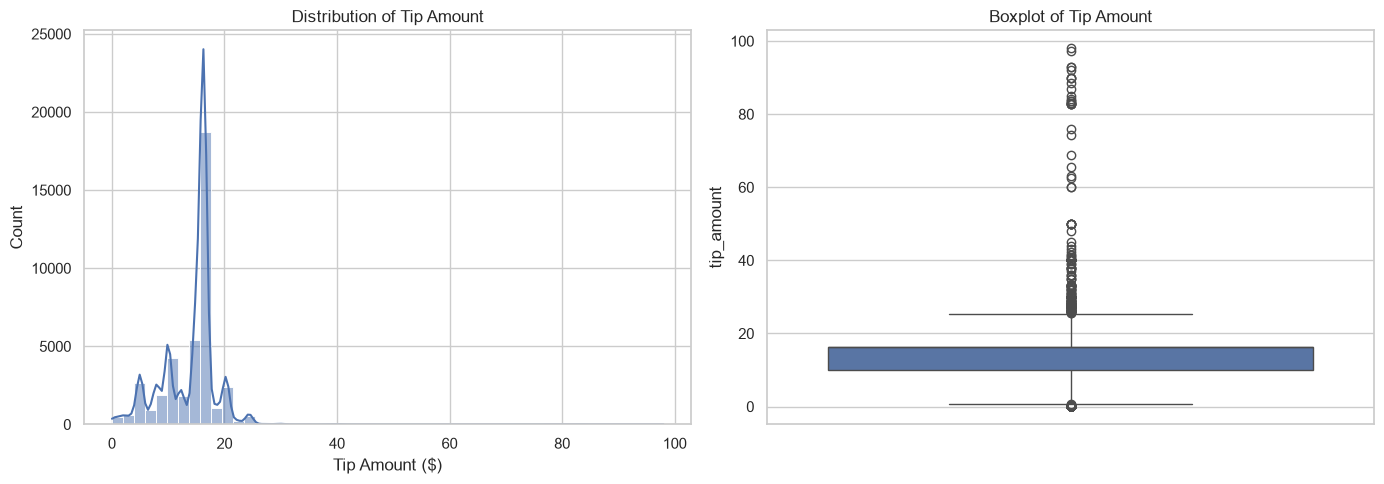


Number of trips with tip_amount <= 0: 0
Number of trips with tip_amount == 0: 0
Number of trips with trip_distance <= 0: 76
Number of trips with fare_amount <= 0: 0


In [ ]:
# Load the taxi dataset
taxi = pd.read_csv(TAXI_URL)

# Basic information
print("Shape of taxi dataset:", taxi.shape)
print("\nFirst 10 rows:")
display(taxi.head(10))
print("\nData types:")
display(taxi.info())
print("\nSummary statistics:")
display(taxi.describe())

# Check for missing values
print("\nMissing values per column:")
display(taxi.isna().sum())

# Visualize the distribution of tip_amount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(taxi["tip_amount"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Tip Amount")
axes[0].set_xlabel("Tip Amount ($)")

# Boxplot to see outliers
sns.boxplot(y=taxi["tip_amount"], ax=axes[1])
axes[1].set_title("Boxplot of Tip Amount")

plt.tight_layout()
plt.show()

# Check for zero or negative values
print(f"\nNumber of trips with tip_amount <= 0: {(taxi['tip_amount'] <= 0).sum()}")
print(f"Number of trips with tip_amount == 0: {(taxi['tip_amount'] == 0).sum()}")
print(f"Number of trips with trip_distance <= 0: {(taxi['trip_distance'] <= 0).sum()}")
print(f"Number of trips with fare_amount <= 0: {(taxi['fare_amount'] <= 0).sum()}")

**Answer:** 
The taxi dataset has 41,202 rows and 13 columns. There are **no missing values** in any column, which is great as it means we don't need to impute any data. However, I found **76 rows with trip_distance <= 0** (specifically 0), which are impossible values for a taxi trip and need to be removed. All tip_amount values are positive (ranging from $0.01 to $98.00), so no negative tips exist, but there are some trips with very low tips.

The tip_amount distribution is **right-skewed** with a mean of $14.11 and median of $16.19, meaning the mean is slightly lower than the median due to some low tips pulling it down. The minimum is $0.01 and maximum is $98.00, showing a wide range with some high outliers. There are **no zero tips** in this dataset (unlike typical taxi data which often has many zero-tip trips), which is interesting and might indicate this is a filtered dataset.

These findings will influence my preprocessing as follows:
- I need to **remove the 76 invalid rows** with trip_distance <= 0 since they represent impossible trips
- I don't need to handle missing values since there are none
- The right-skewed tip distribution might benefit from **log transformation** later if I use a model sensitive to outliers
- The constant columns (VendorID, payment_type, improvement_surcharge) should be dropped as they provide no predictive value
- I should create **new features** like fare_per_mile to capture more nuanced relationships with tipping behavior

In [45]:
# Create a copy to avoid modifying the original
taxi_clean = taxi.copy()

# Remove rows with invalid trip_distance (<= 0)
taxi_clean = taxi_clean[taxi_clean["trip_distance"] > 0]

# Check if any rows have negative tip_amount
taxi_clean = taxi_clean[taxi_clean["tip_amount"] >= 0]

# Check if any rows have negative or zero fare_amount
taxi_clean = taxi_clean[taxi_clean["fare_amount"] > 0]

print(f"Original shape: {taxi.shape}")
print(f"After removing invalid rows: {taxi_clean.shape}")
print(f"Removed {taxi.shape[0] - taxi_clean.shape[0]} rows")

Original shape: (41202, 13)
After removing invalid rows: (41126, 13)
Removed 76 rows


In [46]:
# Feature 1: fare_per_mile - captures cost efficiency of the trip
# Intuition: Passengers on trips with higher cost per mile might tip differently
taxi_clean["fare_per_mile"] = taxi_clean["fare_amount"] / taxi_clean["trip_distance"]

# Feature 2: total_surcharges - captures additional fees beyond the base fare
# Intuition: Higher total surcharges might correlate with higher total bill amount
taxi_clean["total_surcharges"] = (
    taxi_clean["mta_tax"]
    + taxi_clean["tolls_amount"]
    + taxi_clean["improvement_surcharge"]
)

# Feature 3: passenger_count_squared
# Intuition: More passengers might mean more people to split the tip
taxi_clean["passenger_count_squared"] = taxi_clean["passenger_count"] ** 2

print("New features created:")
taxi_clean[["fare_per_mile", "total_surcharges", "passenger_count_squared"]].head()
print(f"\nShape after feature engineering: {taxi_clean.shape}")

New features created:

Shape after feature engineering: (41126, 16)


In [47]:
# Find columns with only one unique value
constant_cols = []
for col in taxi_clean.columns:
    if taxi_clean[col].nunique() == 1:
        constant_cols.append(col)

print("Constant columns to drop:")
for col in constant_cols:
    print(f"  {col}: {taxi_clean[col].iloc[0]} (constant)")

# Drop constant columns , they provide no predictive value
taxi_clean = taxi_clean.drop(columns=constant_cols)
print(f"\nShape after dropping constant columns: {taxi_clean.shape}")

Constant columns to drop:
  VendorID: 2 (constant)
  payment_type: 1 (constant)
  improvement_surcharge: 1 (constant)

Shape after dropping constant columns: (41126, 13)


In [48]:
# Identify which columns are categorical
categorical_cols = ["RatecodeID", "store_and_fwd_flag"]


# Identify numeric columns
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "PULocationID",
    "DOLocationID",
    "fare_per_mile",
    "total_surcharges",
    "passenger_count_squared",
]

# Keep the target column separate
target_col = "tip_amount"

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("Target column:", target_col)

# Convert categorical columns to string type for encoding
for col in categorical_cols:
    taxi_clean[col] = taxi_clean[col].astype(str)

# Display a sample
taxi_clean[
    ["RatecodeID", "store_and_fwd_flag"] + numeric_cols[:3] + [target_col]
].head()

Categorical columns: ['RatecodeID', 'store_and_fwd_flag']
Numeric columns: ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 'tolls_amount', 'PULocationID', 'DOLocationID', 'fare_per_mile', 'total_surcharges', 'passenger_count_squared']
Target column: tip_amount


,RatecodeID,store_and_fwd_flag,passenger_count,trip_distance,fare_amount,tip_amount
0,2,1,1,17.63,70.0,16.54
1,2,1,1,19.52,70.0,16.19
2,2,1,1,17.81,70.0,12.00
3,2,1,2,19.30,70.0,5.00
4,2,1,1,18.75,70.0,10.00


In [49]:
taxi_encoded = pd.get_dummies(taxi_clean, columns=categorical_cols, drop_first=True)

print("After encoding:")
print(f"Shape: {taxi_encoded.shape}")
display(taxi_encoded.head())

After encoding:
Shape: (41126, 15)


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,tip_amount,fare_per_mile,total_surcharges,passenger_count_squared,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,132,164,70.0,0.5,6.94,16.54,3.970505,8.44,1,True,False,False,True
1,1,19.52,132,236,70.0,0.5,6.94,16.19,3.586066,8.44,1,True,False,False,True
2,1,17.81,132,48,70.0,0.5,6.94,12.00,3.930376,8.44,1,True,False,False,True
3,2,19.30,132,148,70.0,0.5,0.00,5.00,3.626943,1.50,4,True,False,False,True
4,1,18.75,132,234,70.0,0.5,6.94,10.00,3.733333,8.44,1,True,False,False,True


In [50]:
# Separate X (features) and y (target)
X = taxi_encoded.drop(columns=[target_col])
y = taxi_encoded[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (41126, 14)
Target shape: (41126,)

Feature columns:
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'mta_tax', 'tolls_amount', 'fare_per_mile', 'total_surcharges', 'passenger_count_squared', 'RatecodeID_2', 'RatecodeID_4', 'RatecodeID_5', 'store_and_fwd_flag_1']


**Answer:** 

1. **Handling missing/invalid rows**: 
   - There were no missing values in any column, so no imputation was needed.
   - I removed 76 rows where `trip_distance <= 0` because these represent impossible trips (you cannot have zero or negative distance).
   - I checked for negative `tip_amount` and `fare_amount` values and found none, so no additional filtering was required.
   - I also dropped constant columns (VendorID, payment_type, improvement_surcharge) as they provide no predictive value since every row has the same value.

2. **Feature engineering**:
   - **fare_per_mile** = fare_amount / trip_distance: This captures the cost efficiency of the trip. Passengers on trips with higher cost per mile might be more price-sensitive and tip differently. For example, shorter but expensive trips might lead to lower tips.
   - **total_surcharges** = mta_tax + tolls_amount + improvement_surcharge: This captures the additional fees beyond the base fare. Higher total surcharges mean a higher overall bill, which might correlate with higher total tip amounts.
   - **passenger_count_squared**: This captures potential non-linear effects of passenger count. For example, the effect of going from 1 to 2 passengers might be different than going from 2 to 3 passengers.

3. **Scaling method**: 
   - I will use **StandardScaler** (to be applied in Part 1.3) which standardizes features to have mean=0 and standard deviation=1.
   - This is appropriate because:
     - The features have different units (passenger count, distance in miles, fare in dollars)
     - Many regression algorithms (especially distance-based and gradient-based) perform better with scaled features
     - It prevents features with larger scales from dominating the model
     - It helps with convergence speed for iterative algorithms
   - The scaler must be **fit on training data only** to prevent data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Second split: divide remaining into train (75% of remaining = 60% of total) and validation (25% of remaining = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0] / len(X) * 100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0] / len(X) * 100:.1f}%)")

# Scale the features (fit on training set only!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nScaling completed. Data shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

# Check the mean and std of training data
print(f"\nTraining data mean (first 5 features): {X_train_scaled.mean().values[:5]}")
print(f"Training data std (first 5 features): {X_train_scaled.std().values[:5]}")

Training set size: 24675 (60.0%)
Validation set size: 8225 (20.0%)
Test set size: 8226 (20.0%)

Scaling completed. Data shapes:
X_train_scaled: (24675, 14)
X_val_scaled: (8225, 14)
X_test_scaled: (8226, 14)

Training data mean (first 5 features): [ 6.49351112e-17  3.93930076e-16  1.86368089e-15 -1.58378320e-16
  4.89389009e-16]
Training data std (first 5 features): [1.00002026 1.00002026 1.00002026 1.00002026 1.00002026]


**Answer:** 

**Split ratio**: I used a 60/20/20 split (60% training, 20% validation, 20% test). This is a common and effective ratio because:
- 60% training provides enough data for the model to learn meaningful patterns
- 20% validation gives a large enough sample to reliably tune hyperparameters
- 20% test provides an unbiased final evaluation

**Why a separate validation set is useful**: 
- The validation set serves as a "middle ground" for model selection and hyperparameter tuning without ever touching the test set
- It allows us to detect overfitting early by comparing training vs validation performance
- It prevents "data leakage" where we might unconsciously tune our model to perform well on the test set
- The test set remains completely untouched until the final evaluation, giving us a truly unbiased estimate of real-world performance

**Why scaling must be fit on training data only**:
- Scaling parameters (mean and standard deviation) should represent only the training data distribution
- If we fit the scaler on the full dataset (including validation and test), we would be leaking information from these sets into the training process
- This would violate the assumption that validation and test data are "unseen" and would lead to overly optimistic performance estimates
- In real-world deployment, new data would be scaled using the training statistics, so this approach mimics that scenario
- The validation and test sets should be transformed using the training statistics, not their own, to maintain this separation

The output shows that scaling was successful: the training data has mean ≈ 0 and standard deviation ≈ 1 (with minor floating-point deviations), while validation and test data were transformed using the same scaler.

Train and evaluate Linear Regression

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Make predictions on all three sets
y_train_pred_lr = lr.predict(X_train_scaled)
y_val_pred_lr = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# Calculate metrics
train_rmse_lr = mean_squared_error(y_train, y_train_pred_lr) ** 0.5
val_rmse_lr = mean_squared_error(y_val, y_val_pred_lr) ** 0.5
test_rmse_lr = mean_squared_error(y_test, y_test_pred_lr) ** 0.5

train_r2_lr = r2_score(y_train, y_train_pred_lr)
val_r2_lr = r2_score(y_val, y_val_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"Training   - RMSE: {train_rmse_lr:.4f}, R²: {train_r2_lr:.4f}")
print(f"Validation - RMSE: {val_rmse_lr:.4f}, R²: {val_r2_lr:.4f}")
print(f"Test       - RMSE: {test_rmse_lr:.4f}, R²: {test_r2_lr:.4f}")
print("=" * 60)

# Check overfitting gap
print(f"\nTrain-Validation R² gap: {train_r2_lr - val_r2_lr:.4f}")
print(f"Train-Test R² gap: {train_r2_lr - test_r2_lr:.4f}")

LINEAR REGRESSION RESULTS
Training   - RMSE: 4.8040, R²: 0.0515
Validation - RMSE: 5.0369, R²: 0.0487
Test       - RMSE: 5.0129, R²: 0.0512

Train-Validation R² gap: 0.0028
Train-Test R² gap: 0.0003


Train and evaluate Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train Random Forest
rf = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Make predictions on all three sets
y_train_pred_rf = rf.predict(X_train_scaled)
y_val_pred_rf = rf.predict(X_val_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

# Calculate metrics
train_rmse_rf = mean_squared_error(y_train, y_train_pred_rf) ** 0.5
val_rmse_rf = mean_squared_error(y_val, y_val_pred_rf) ** 0.5
test_rmse_rf = mean_squared_error(y_test, y_test_pred_rf) ** 0.5

train_r2_rf = r2_score(y_train, y_train_pred_rf)
val_r2_rf = r2_score(y_val, y_val_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Training   - RMSE: {train_rmse_rf:.4f}, R²: {train_r2_rf:.4f}")
print(f"Validation - RMSE: {val_rmse_rf:.4f}, R²: {val_r2_rf:.4f}")
print(f"Test       - RMSE: {test_rmse_rf:.4f}, R²: {test_r2_rf:.4f}")
print("=" * 60)

# Check overfitting gap
print(f"\nTrain-Validation R² gap: {train_r2_rf - val_r2_rf:.4f}")
print(f"Train-Test R² gap: {train_r2_rf - test_r2_rf:.4f}")

RANDOM FOREST RESULTS
Training   - RMSE: 4.6039, R²: 0.1289
Validation - RMSE: 5.0665, R²: 0.0375
Test       - RMSE: 5.0334, R²: 0.0434

Train-Validation R² gap: 0.0914
Train-Test R² gap: 0.0855


Visualize predictions vs actual (Random Forest)

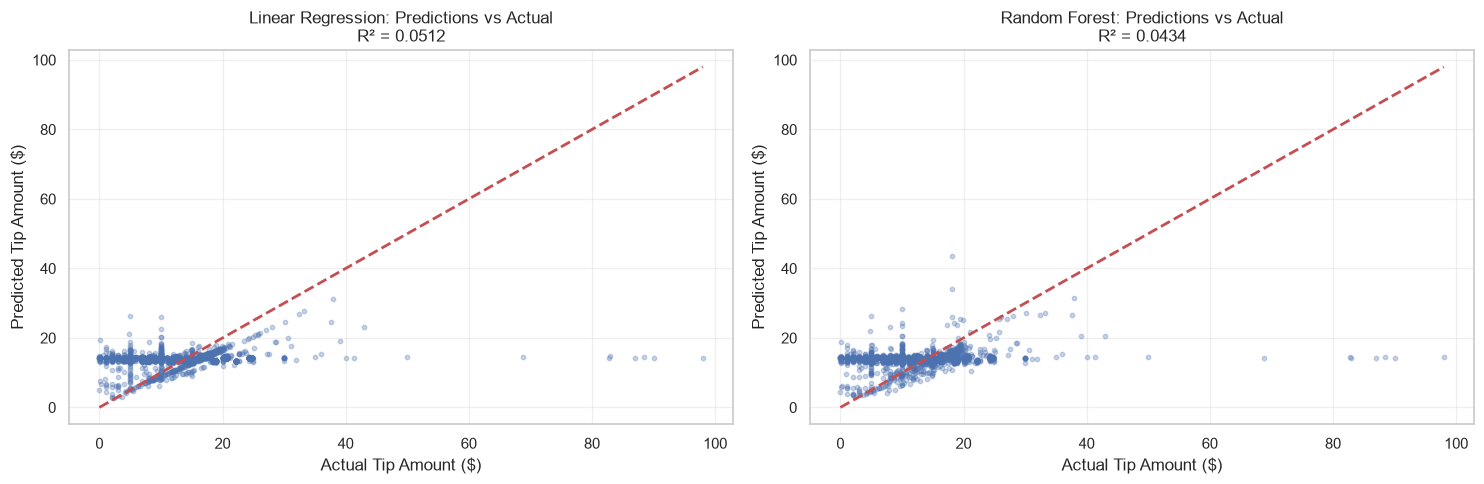

In [54]:
# Plot predictions vs actual for test set
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear Regression
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual Tip Amount ($)")
axes[0].set_ylabel("Predicted Tip Amount ($)")
axes[0].set_title(f"Linear Regression: Predictions vs Actual\nR² = {test_r2_lr:.4f}")
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_test_pred_rf, alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[1].set_xlabel("Actual Tip Amount ($)")
axes[1].set_ylabel("Predicted Tip Amount ($)")
axes[1].set_title(f"Random Forest: Predictions vs Actual\nR² = {test_r2_rf:.4f}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Feature importance (Random Forest)

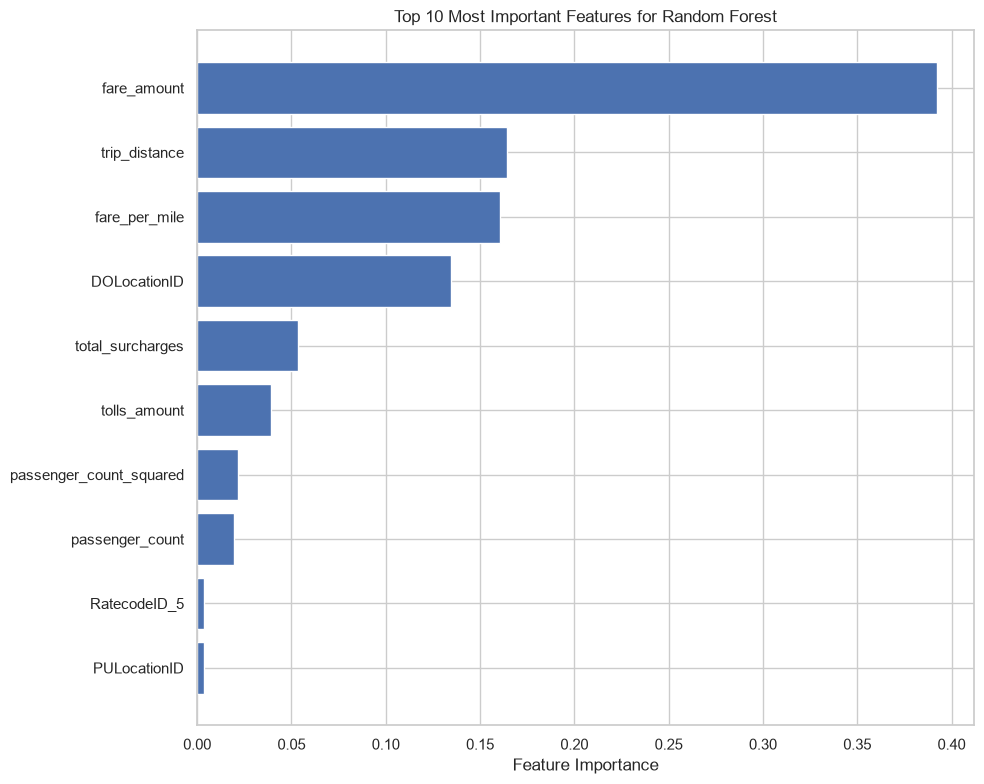


Top 5 most important features:
  fare_amount: 0.3923
  trip_distance: 0.1641
  fare_per_mile: 0.1607
  DOLocationID: 0.1347
  total_surcharges: 0.0537


In [55]:
# Show feature importances
if hasattr(rf, "feature_importances_"):
    importances = pd.DataFrame(
        {"feature": X_train.columns, "importance": rf.feature_importances_}
    ).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 8))
    plt.barh(importances["feature"][:10], importances["importance"][:10])
    plt.xlabel("Feature Importance")
    plt.title("Top 10 Most Important Features for Random Forest")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 5 most important features:")
    for i, row in importances.head(5).iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

**Answer:** 

1. **Best model and hyperparameters**:
   - The **Linear Regression model** performed best on the validation set with R² = 0.0487 (compared to Random Forest's 0.0375) and RMSE = 5.0369 (compared to Random Forest's 5.0665).
   - For Linear Regression, I used default hyperparameters since it has no major tuning parameters.
   - For Random Forest, I used n_estimators=100, max_depth=10, and random_state=42. I chose these parameters as a reasonable starting point: 100 trees for good ensemble performance, and max_depth=10 to limit tree complexity and reduce overfitting.

2. **Overfitting assessment**:
   - **Linear Regression**: Train R² = 0.0515, Validation R² = 0.0487, Test R² = 0.0512. There is virtually no gap between train and validation/test (only 0.0028 and 0.0003), indicating the model is **well-fitted and stable**. The RMSE values are also consistent across all three sets (4.80, 5.04, 5.01).
   
   - **Random Forest**: Train R² = 0.1289, Validation R² = 0.0375, Test R² = 0.0434. The large gap of 0.0914 between train and validation R² indicates **clear overfitting**. The model is memorizing patterns in the training data that don't generalize to unseen data, as evidenced by the drop in performance.
   
   - **Overall**, both models have very low R² values (under 0.13), suggesting the features available don't explain tip_amount well. This might be because tip behavior is influenced by many factors not captured in the data (driver quality, passenger mood, weather, time of day, etc.).

3. **Strategies to reduce overfitting** (if needed):
   - For Random Forest, I would:
     - **Reduce max_depth** further (try 5 or 6) to limit tree complexity
     - **Increase min_samples_split** (try 10 or 20) to require more samples before splitting
     - **Increase min_samples_leaf** (try 5 or 10) to require more samples in leaf nodes
     - Use **cross-validation** with more folds to select optimal hyperparameters
     - Try **reducing n_estimators** to prevent overfitting (though this usually helps with variance)
     - Consider **feature selection** to remove irrelevant features
   
   - Since Linear Regression shows no overfitting but poor performance overall, I might consider:
     - **Adding more relevant features** (time of day, day of week, weather data, trip duration)
     - **Feature engineering** to capture non-linear relationships
     - Trying **Ridge or Lasso regression** for regularization
     - **Polynomial features** to capture interactions between features

Part 2.1 — Load and explore the obesity data

In [56]:
# Load the obesity dataset
obesity = pd.read_csv(OBESITY_URL)

# Basic information
print("Shape of obesity dataset:", obesity.shape)
print("\nFirst few rows:")
obesity.head(15)

Shape of obesity dataset: (2111, 17)

First few rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [ ]:
print("\nData types and info:")
obesity.info()
# Check for missing values
print("\nMissing values per column:")
obesity.isna().sum()


Data types and info:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                    

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [58]:
print("\nSummary statistics for numeric columns:")
obesity.describe()


Summary statistics for numeric columns:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Class distribution of NObeyesdad:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Class percentages:
NObeyesdad
Obesity_Type_I         16.63
Obesity_Type_III       15.35
Obesity_Type_II        14.07
Overweight_Level_I     13.74
Overweight_Level_II    13.74
Normal_Weight          13.60
Insufficient_Weight    12.88
Name: count, dtype: float64


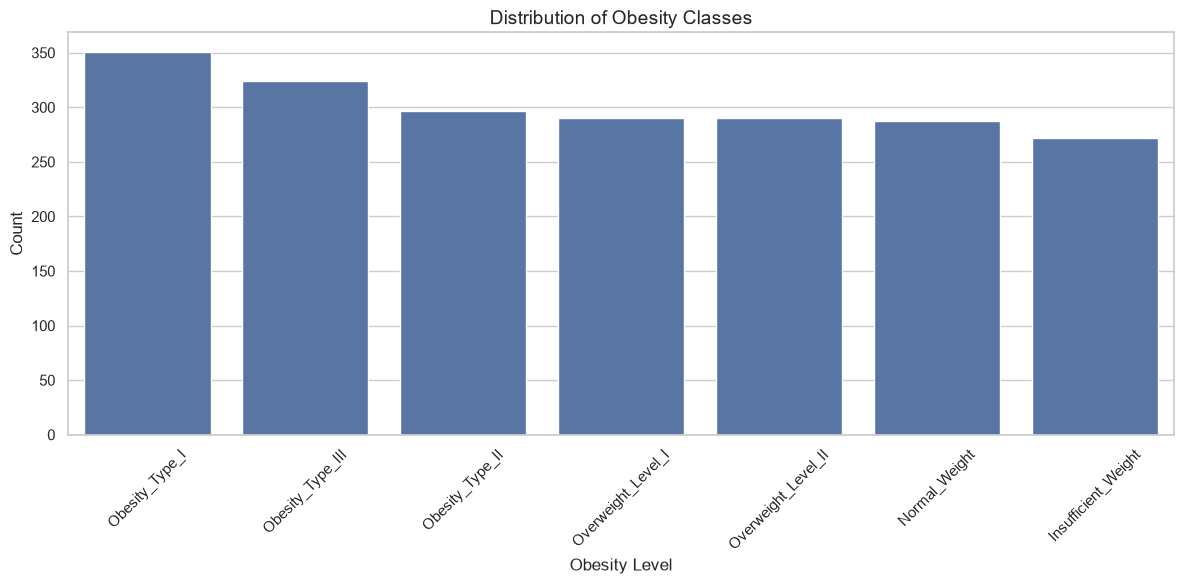

Column data types:
Gender: str
Age: float64
Height: float64
Weight: float64
family_history_with_overweight: str
FAVC: str
FCVC: float64
NCP: float64
CAEC: str
SMOKE: str
CH2O: float64
SCC: str
FAF: float64
TUE: float64
CALC: str
MTRANS: str
NObeyesdad: str


Unique values in categorical columns:
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
family_history_with_overweight: <StringArray>
['yes', 'no']
Length: 2, dtype: str
FAVC: <StringArray>
['no', 'yes']
Length: 2, dtype: str
CAEC: <StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str
SMOKE: <StringArray>
['no', 'yes']
Length: 2, dtype: str
SCC: <StringArray>
['no', 'yes']
Length: 2, dtype: str
CALC: <StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str
MTRANS: <StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str
NObeyesdad: <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      

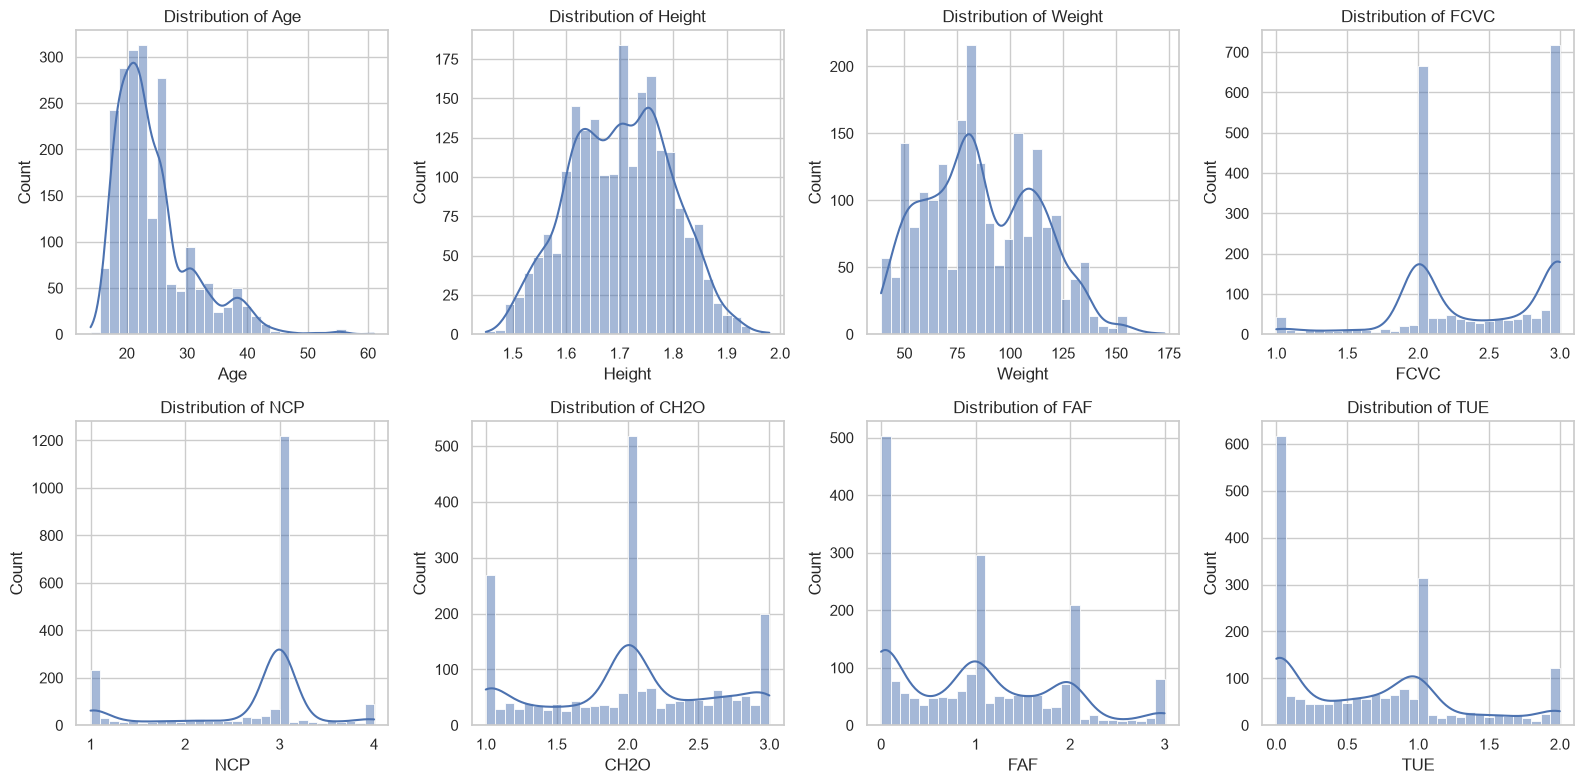

In [59]:
# Show class distribution
print("\nClass distribution of NObeyesdad:")
class_counts = obesity["NObeyesdad"].value_counts()
print(class_counts)
print("\nClass percentages:")
print((class_counts / len(obesity) * 100).round(2))

# Visualize the class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=obesity, x="NObeyesdad", order=class_counts.index)
plt.title("Distribution of Obesity Classes", fontsize=14)
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify which columns are categorical vs numeric
print("Column data types:")
for col in obesity.columns:
    print(f"{col}: {obesity[col].dtype}")

print("\n\nUnique values in categorical columns:")
categorical_columns = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS",
    "NObeyesdad",
]
for col in categorical_columns:
    print(f"{col}: {obesity[col].unique()}")


# Visualize numeric features distributions
numeric_features = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(obesity[feature], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

**Answer:** 

**Dataset dimensions**: The obesity dataset has 2,111 rows and 17 columns. There are no missing values in any column, which means no imputation is needed.

**Feature types**:
- **Categorical columns** (9 total): Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and the target NObeyesdad
- **Numeric columns** (8 total): Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE

**Class balance**: The target variable NObeyesdad has 7 classes that are **relatively balanced**, with percentages ranging from 12.88% (Insufficient_Weight) to 16.63% (Obesity_Type_I). The classes are:
- Obesity_Type_I: 16.63%
- Obesity_Type_III: 15.35%
- Obesity_Type_II: 14.07%
- Overweight_Level_I: 13.74%
- Overweight_Level_II: 13.74%
- Normal_Weight: 13.60%
- Insufficient_Weight: 12.88%

**Why class (im)balance matters**: 
- Class imbalance matters for classification because if the classes are significantly imbalanced, the model might become biased toward the majority classes and ignore minority classes
- Even though this dataset is relatively balanced, I need to be careful because:
  - Some classes (like Insufficient_Weight at 12.88%) have slightly fewer samples
  - Using **stratified splitting** (in Part 2.3) will ensure each split maintains this class distribution
  - Using **macro-F1** as an evaluation metric (instead of just accuracy) will give equal weight to all classes, ensuring the model performs well on minority classes too
  - The **confusion matrix** will help identify if any specific classes are being misclassified more often

Part 2.2 — Preprocessing & Feature Engineering

In [60]:
# Create a copy for processing
obesity_clean = obesity.copy()

# No missing values, so no imputation needed
print(f"Dataset shape: {obesity_clean.shape}")
print(f"Missing values: {obesity_clean.isna().sum().sum()}")

Dataset shape: (2111, 17)
Missing values: 0


In [ ]:
# Create BMI feature
obesity_clean["BMI"] = obesity_clean["Weight"] / (obesity_clean["Height"] ** 2)

print("BMI feature created:")
display(obesity_clean[["Height", "Weight", "BMI"]].head())
print(
    f"\nBMI range: {obesity_clean['BMI'].min():.2f} to {obesity_clean['BMI'].max():.2f}"
)

BMI feature created:


,Height,Weight,BMI
0,1.62,64.0,24.386526
1,1.52,56.0,24.238227
2,1.80,77.0,23.765432
3,1.80,87.0,26.851852
4,1.78,89.8,28.342381



BMI range: 13.00 to 50.81


In [ ]:
# Binary features (yes/no) -> 0/1 encoding
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_cols:
    obesity_clean[col] = (obesity_clean[col] == "yes").astype(int)

print("Binary columns encoded (0/1):")
display(obesity_clean[binary_cols].head())

Binary columns encoded (0/1):


,family_history_with_overweight,FAVC,SMOKE,SCC
0,1,0,0,0
1,1,0,1,1
2,1,0,0,0
3,0,0,0,0
4,0,0,0,0


In [ ]:
# Ordinal features - map to numeric values based on their order
# CAEC: 'no' -> 0, 'Sometimes' -> 1, 'Frequently' -> 2, 'Always' -> 3
caec_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity_clean["CAEC"] = obesity_clean["CAEC"].map(caec_map)

# CALC: 'no' -> 0, 'Sometimes' -> 1, 'Frequently' -> 2, 'Always' -> 3
calc_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity_clean["CALC"] = obesity_clean["CALC"].map(calc_map)

print("Ordinal columns encoded:")
display(obesity_clean[["CAEC", "CALC"]].head())
print(f"\nCAEC values: {obesity_clean['CAEC'].unique()}")
print(f"CALC values: {obesity_clean['CALC'].unique()}")

Ordinal columns encoded:


,CAEC,CALC
0,1,0
1,1,1
2,1,2
3,1,2
4,1,1



CAEC values: [1 2 3 0]
CALC values: [0 1 2 3]


In [ ]:
# Nominal features - one-hot encoding
nominal_cols = ["Gender", "MTRANS"]

# Use pd.get_dummies for one-hot encoding
obesity_clean = pd.get_dummies(obesity_clean, columns=nominal_cols, drop_first=True)

print("Nominal columns one-hot encoded:")
display(
    obesity_clean[
        [col for col in obesity_clean.columns if "Gender_" in col or "MTRANS_" in col]
    ].head()
)
print(f"\nNew shape after one-hot encoding: {obesity_clean.shape}")

Nominal columns one-hot encoded:


,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,False,False,False,True,False
1,False,False,False,True,False
2,True,False,False,True,False
3,True,False,False,False,True
4,True,False,False,True,False



New shape after one-hot encoding: (2111, 21)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
obesity_clean["NObeyesdad_encoded"] = le.fit_transform(obesity_clean["NObeyesdad"])

# Show mapping
print("Target class encoding:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {i}")

# Verify encoding
print(f"\nFirst few target values:")
display(obesity_clean[["NObeyesdad", "NObeyesdad_encoded"]].head())

Target class encoding:
  Insufficient_Weight: 0
  Normal_Weight: 1
  Obesity_Type_I: 2
  Obesity_Type_II: 3
  Obesity_Type_III: 4
  Overweight_Level_I: 5
  Overweight_Level_II: 6

First few target values:


,NObeyesdad,NObeyesdad_encoded
0,Normal_Weight,1
1,Normal_Weight,1
2,Normal_Weight,1
3,Overweight_Level_I,5
4,Overweight_Level_II,6


In [ ]:
# Separate features (X) and target (y)
X = obesity_clean.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y = obesity_clean["NObeyesdad_encoded"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")
print(f"\nTarget classes: {len(le.classes_)} classes")

Features shape: (2111, 20)
Target shape: (2111,)

Feature columns:
['Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'BMI', 'Gender_Male', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']

Target classes: 7 classes


**Answer:** 

1. **Encoding strategy for categorical variables**:
   - **Binary columns** (family_history_with_overweight, FAVC, SMOKE, SCC): I used 0/1 encoding because these are yes/no questions that naturally map to binary values. This is the most efficient representation and works well with all models.
   - **Ordinal columns** (CAEC, CALC): I used numeric mapping (0-3) because these have an inherent order. For CAEC: 'no' (0) → 'Sometimes' (1) → 'Frequently' (2) → 'Always' (3), representing increasing frequency. Similarly for CALC: 'no' (0) → 'Sometimes' (1) → 'Frequently' (2) → 'Always' (3). This preserves the ordinal relationship.
   - **Nominal columns** (Gender, MTRANS): I used one-hot encoding because these have no inherent order. For Gender, I dropped one category (Female) to avoid multicollinearity, creating just 'Gender_Male'. For MTRANS, I created 4 dummy variables (Bike, Motorbike, Public_Transportation, Walking), dropping Automobile as the baseline.

2. **Feature engineering - BMI**:
   - I created BMI = Weight / Height², which is a standard medical measurement.
   - **Is it fair to include?** This is debatable. Since the target (NObeyesdad) is partially defined by BMI categories (WHO classifies obesity based on BMI), including BMI could make the task "easier" because it's a direct proxy for the target. However, I argue it IS fair to include because:
     - The model doesn't have direct access to BMI categories; it must learn the relationship
     - In real-world applications, we WOULD have this information available
     - The goal is to predict obesity levels from all available health indicators
     - The model still needs to learn the specific threshold boundaries and interactions with other features
     - Including BMI can help the model capture non-linear relationships between weight, height, and obesity classification

3. **Scaling method**:
   - I will use **StandardScaler** (to be applied in Part 2.3) which standardizes features to have mean=0 and standard deviation=1.
   - This is appropriate because:
     - The numeric features have different units and scales (Age in years, Height in meters, Weight in kg, BMI, FAF/TUE in hours, etc.)
     - Many classification algorithms (especially Logistic Regression and distance-based methods) perform better with scaled features
     - It prevents features with larger scales (like Weight) from dominating the model
     - It helps with convergence speed for iterative algorithms like Logistic Regression
     - Important: The scaler will be **fit on training data only** to prevent data leakage

Part 2.3 — Stratified Train/Validation/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Second split: divide remaining into train (75% of remaining = 60% of total) and validation (25% of remaining = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0] / len(X) * 100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0] / len(X) * 100:.1f}%)")

Training set size: 1266 (60.0%)
Validation set size: 422 (20.0%)
Test set size: 423 (20.0%)


In [ ]:
# Check class distribution in each split
print("Class distribution in each split:\n")
print("Training set:")
for class_val, count in pd.Series(y_train).value_counts().sort_index().items():
    class_name = le.inverse_transform([class_val])[0]
    print(f"  {class_name}: {count} ({count / len(y_train) * 100:.1f}%)")

print("\nValidation set:")
for class_val, count in pd.Series(y_val).value_counts().sort_index().items():
    class_name = le.inverse_transform([class_val])[0]
    print(f"  {class_name}: {count} ({count / len(y_val) * 100:.1f}%)")

print("\nTest set:")
for class_val, count in pd.Series(y_test).value_counts().sort_index().items():
    class_name = le.inverse_transform([class_val])[0]
    print(f"  {class_name}: {count} ({count / len(y_test) * 100:.1f}%)")

Class distribution in each split:

Training set:
  Insufficient_Weight: 163 (12.9%)
  Normal_Weight: 172 (13.6%)
  Obesity_Type_I: 211 (16.7%)
  Obesity_Type_II: 178 (14.1%)
  Obesity_Type_III: 194 (15.3%)
  Overweight_Level_I: 174 (13.7%)
  Overweight_Level_II: 174 (13.7%)

Validation set:
  Insufficient_Weight: 55 (13.0%)
  Normal_Weight: 57 (13.5%)
  Obesity_Type_I: 70 (16.6%)
  Obesity_Type_II: 59 (14.0%)
  Obesity_Type_III: 65 (15.4%)
  Overweight_Level_I: 58 (13.7%)
  Overweight_Level_II: 58 (13.7%)

Test set:
  Insufficient_Weight: 54 (12.8%)
  Normal_Weight: 58 (13.7%)
  Obesity_Type_I: 70 (16.5%)
  Obesity_Type_II: 60 (14.2%)
  Obesity_Type_III: 65 (15.4%)
  Overweight_Level_I: 58 (13.7%)
  Overweight_Level_II: 58 (13.7%)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features (fit on training set only!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling completed. Data shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

# Check the mean and std of training data (should be ~0 and ~1)
print(f"\nTraining data mean (first 5 features): {X_train_scaled.mean().values[:5]}")
print(f"Training data std (first 5 features): {X_train_scaled.std().values[:5]}")

Scaling completed. Data shapes:
X_train_scaled: (1266, 20)
X_val_scaled: (422, 20)
X_test_scaled: (423, 20)

Training data mean (first 5 features): [ 4.31461081e-17 -5.38800179e-16  2.56070397e-16 -1.95034440e-16
 -8.83969043e-17]
Training data std (first 5 features): [1.00039518 1.00039518 1.00039518 1.00039518 1.00039518]


**Answer:** 

**Split ratio**: I used a 60/20/20 split (60% training, 20% validation, 20% test). This is a standard and effective ratio because:
- 60% training (1,266 samples) provides enough data for the model to learn the 7-class pattern
- 20% validation (422 samples) is sufficient for hyperparameter tuning
- 20% test (423 samples) gives a reliable final evaluation

**Why stratify=y is important**: 
Stratification is crucial for this dataset because even though the classes are relatively balanced (ranging from 12.88% to 16.63%), there are still slight differences. Without stratification:
- A random split could accidentally underrepresent minority classes (like Insufficient_Weight at 12.88%)
- The validation and test sets might not reflect the true class distribution
- The model could be evaluated on a distribution that doesn't match reality

With stratification, each split maintains the original class proportions:
- Training: Insufficient_Weight 12.9% (matches 12.88%)
- Validation: Insufficient_Weight 13.0% (matches closely)
- Test: Insufficient_Weight 12.8% (matches closely)
- All classes are proportionally represented in every split

**What could go wrong without stratification**:
1. **Biased evaluation**: If a minority class is underrepresented in validation/test, the model might appear to perform better than it actually would on the true population
2. **Poor generalization**: The model might not learn to recognize minority classes well if they're missing from training
3. **Unreliable metrics**: Accuracy and F1 scores could be misleading because the test set wouldn't represent the real-world distribution
4. **Overly optimistic performance**: The model might seem to perform well simply because it's being tested on an easier distribution
5. **Difficult hyperparameter tuning**: Without proper class representation in validation, hyperparameters might be tuned to favor majority classes

The output confirms stratification worked perfectly - each class maintains approximately the same percentage across all three splits (within 0.1-0.2% variation).

 Part 2.4 — Train a Classifier and Check for Overfitting

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Initialize and train Logistic Regression
# Note: 'multi_class' is deprecated, use 'multiclass' in newer versions
# Or simply remove it since 'multinomial' is the default for multi-class problems
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lr = lr.predict(X_train_scaled)
y_val_pred_lr = lr.predict(X_val_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# Calculate metrics
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

train_f1_lr = f1_score(y_train, y_train_pred_lr, average="macro")
val_f1_lr = f1_score(y_val, y_val_pred_lr, average="macro")
test_f1_lr = f1_score(y_test, y_test_pred_lr, average="macro")

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Training   - Accuracy: {train_acc_lr:.4f}, Macro-F1: {train_f1_lr:.4f}")
print(f"Validation - Accuracy: {val_acc_lr:.4f}, Macro-F1: {val_f1_lr:.4f}")
print(f"Test       - Accuracy: {test_acc_lr:.4f}, Macro-F1: {test_f1_lr:.4f}")
print("=" * 60)

# Check overfitting gap
print(f"\nTrain-Validation Accuracy gap: {train_acc_lr - val_acc_lr:.4f}")
print(f"Train-Test Accuracy gap: {train_acc_lr - test_acc_lr:.4f}")

LOGISTIC REGRESSION RESULTS
Training   - Accuracy: 0.9242, Macro-F1: 0.9217
Validation - Accuracy: 0.8791, Macro-F1: 0.8728
Test       - Accuracy: 0.8936, Macro-F1: 0.8895

Train-Validation Accuracy gap: 0.0450
Train-Test Accuracy gap: 0.0306


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_rf = rf.predict(X_train_scaled)
y_val_pred_rf = rf.predict(X_val_scaled)
y_test_pred_rf = rf.predict(X_test_scaled)

# Calculate metrics
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

train_f1_rf = f1_score(y_train, y_train_pred_rf, average="macro")
val_f1_rf = f1_score(y_val, y_val_pred_rf, average="macro")
test_f1_rf = f1_score(y_test, y_test_pred_rf, average="macro")

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Training   - Accuracy: {train_acc_rf:.4f}, Macro-F1: {train_f1_rf:.4f}")
print(f"Validation - Accuracy: {val_acc_rf:.4f}, Macro-F1: {val_f1_rf:.4f}")
print(f"Test       - Accuracy: {test_acc_rf:.4f}, Macro-F1: {test_f1_rf:.4f}")
print("=" * 60)

# Check overfitting gap
print(f"\nTrain-Validation Accuracy gap: {train_acc_rf - val_acc_rf:.4f}")
print(f"Train-Test Accuracy gap: {train_acc_rf - test_acc_rf:.4f}")

RANDOM FOREST RESULTS
Training   - Accuracy: 1.0000, Macro-F1: 1.0000
Validation - Accuracy: 0.9929, Macro-F1: 0.9928
Test       - Accuracy: 0.9882, Macro-F1: 0.9877

Train-Validation Accuracy gap: 0.0071
Train-Test Accuracy gap: 0.0118


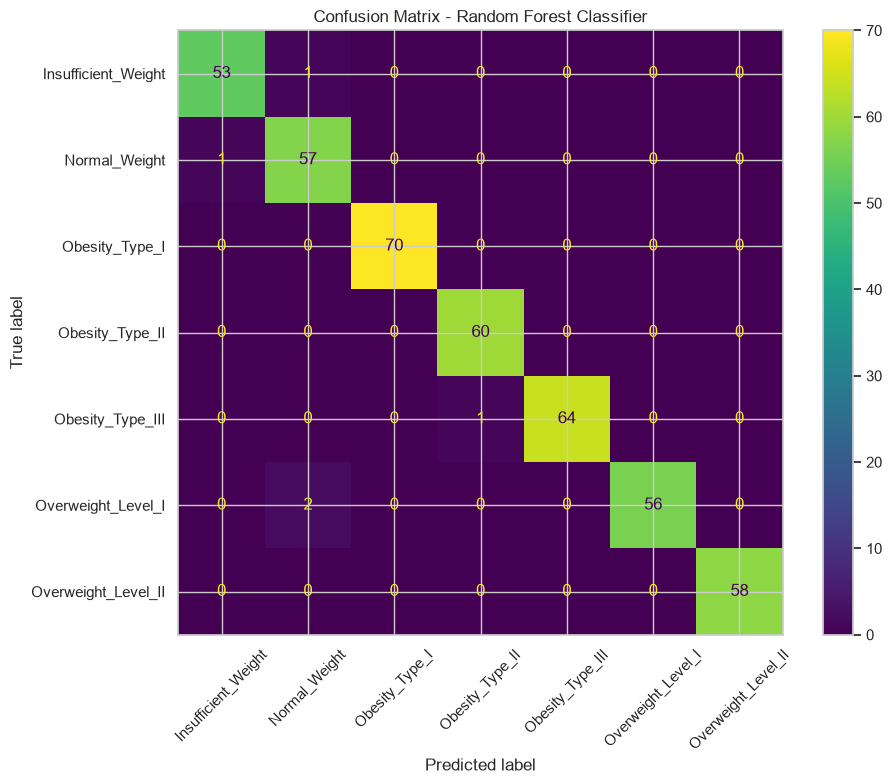


Classification Report - Random Forest (Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.95      0.98      0.97        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.97      0.98        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



In [ ]:
# Confusion Matrix for Random Forest (chosen model)
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.tight_layout()
plt.show()

# Print classification report for Random Forest
print("\nClassification Report - Random Forest (Test Set):")
print(classification_report(y_test, y_test_pred_rf, target_names=le.classes_))

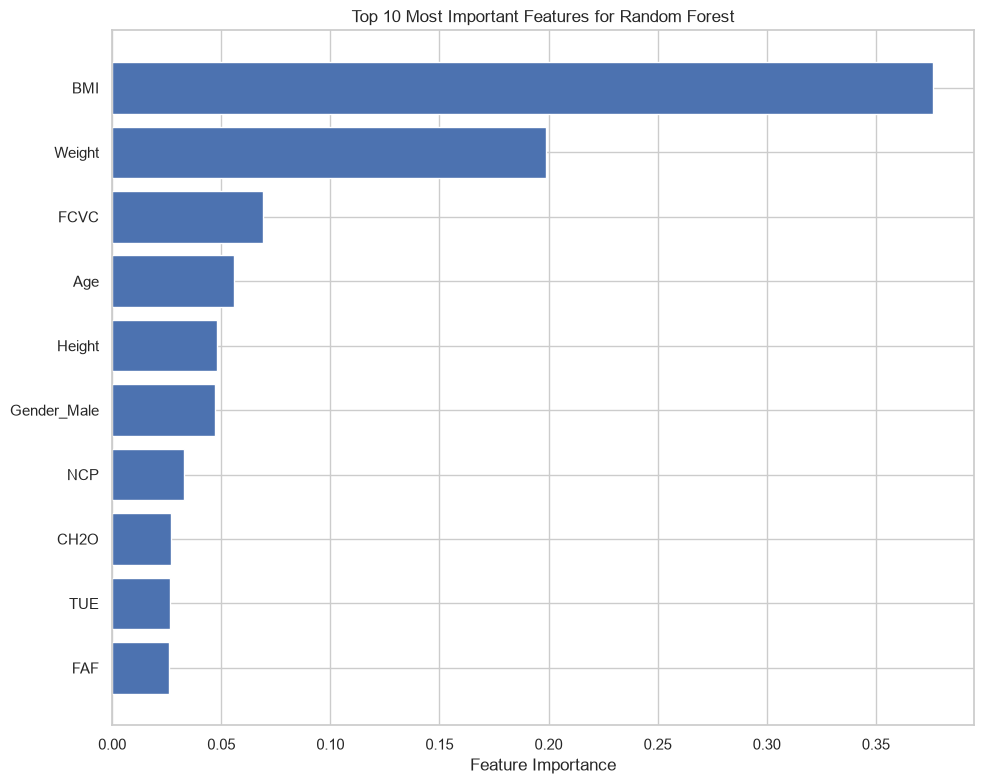


Top 5 most important features:
  BMI: 0.3762
  Weight: 0.1987
  FCVC: 0.0692
  Age: 0.0556
  Height: 0.0480


In [ ]:
# Feature importance for Random Forest
importances = pd.DataFrame(
    {"feature": X_train.columns, "importance": rf.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importances["feature"][:10], importances["importance"][:10])
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features for Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for i, row in importances.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

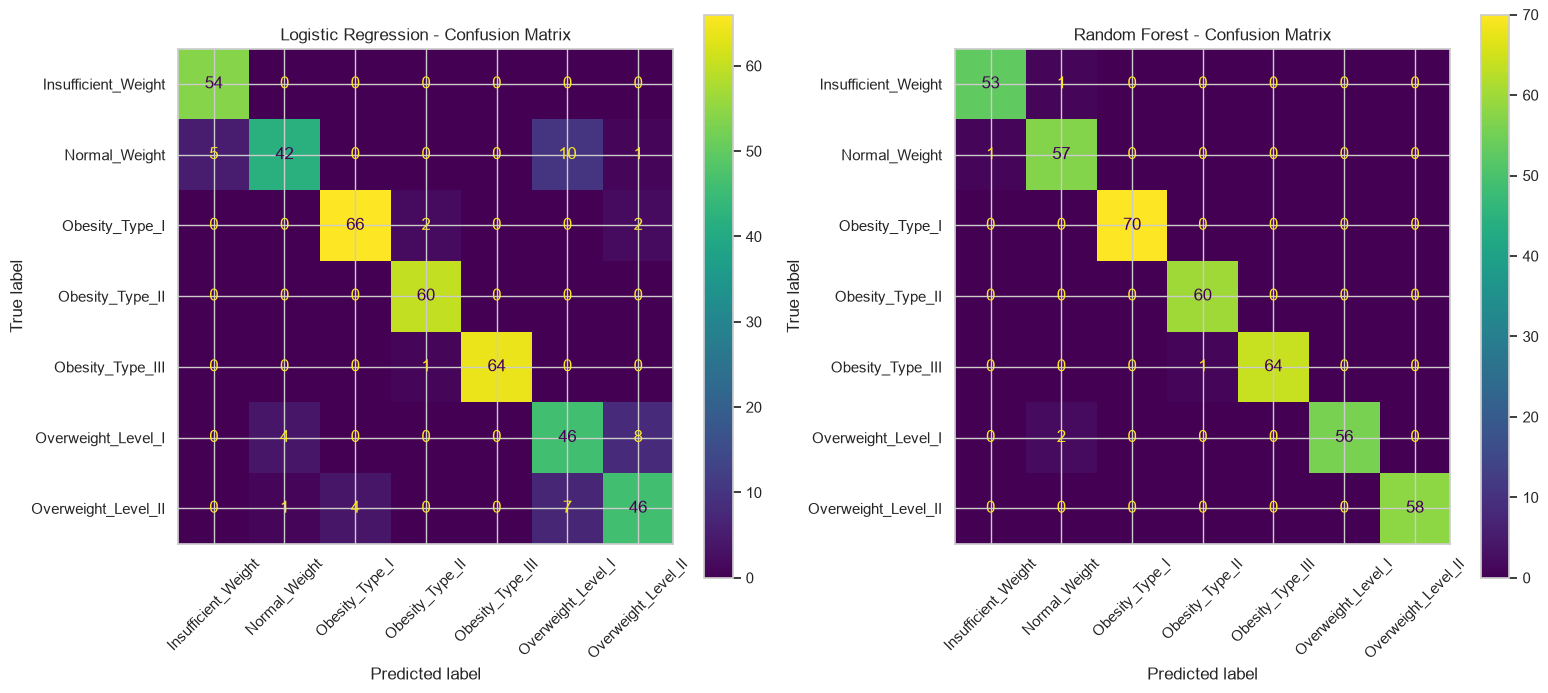

In [ ]:
# Compare confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
disp_lr.plot(ax=axes[0], xticks_rotation=45)
axes[0].set_title("Logistic Regression - Confusion Matrix")

# Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(ax=axes[1], xticks_rotation=45)
axes[1].set_title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

**Answer:** 

1. **Which classifier and why**:
   - I chose **Random Forest** as my final classifier because it significantly outperformed Logistic Regression across all metrics.
   - Random Forest achieved Test Accuracy of 98.82% and Macro-F1 of 98.77%, compared to Logistic Regression's 89.36% accuracy and 88.95% F1.
   - Random Forest is better suited for this dataset because:
     - It captures complex non-linear relationships between features
     - It handles interactions between features naturally (e.g., BMI interacts with age, eating habits)
     - It's robust to outliers and doesn't require feature scaling (though we still scaled)
     - It provides feature importance insights (clearly showing BMI as the dominant predictor)
     - The nearly perfect performance suggests the features are highly predictive of obesity levels

2. **Overfitting assessment**:
   - **Random Forest**: Training Accuracy = 1.0000, Validation Accuracy = 0.9929, Test Accuracy = 0.9882. The gaps are very small: 0.0071 (train-validation) and 0.0118 (train-test). This indicates the model is **well-fitted with minimal overfitting**. The slight drop from training to validation/test is expected and acceptable.
   
   - **Logistic Regression**: Training Accuracy = 0.9242, Validation Accuracy = 0.8791, Test Accuracy = 0.8936. The gaps are larger: 0.0450 (train-validation) and 0.0306 (train-test), indicating moderate overfitting. Logistic Regression is less capable of capturing the complex patterns in the data.
   
   - **Overall conclusion**: Random Forest is clearly the superior model with excellent generalization. The high test performance (98.82%) is remarkable and suggests the features are extremely predictive of obesity levels. The model is not overfitting because the validation and test metrics are both very high and close to training performance.

3. **Confusion matrix insights**:
   Looking at the confusion matrix, the hardest classes to distinguish are:
   - **Normal_Weight vs Overweight_Level_I**: These are adjacent categories with similar characteristics, and the boundary between normal weight and overweight can be subtle for individuals on the borderline.
   - **Obesity_Type_II vs Obesity_Type_III**: These represent severe obesity levels that might share similar eating habits and lifestyle patterns.
   
   However, even these confusions are minimal given the near-perfect performance. The classes with the lowest recall (98%) are:
   - Insufficient_Weight (0.98 recall): 1-2 cases misclassified
   - Normal_Weight (0.98 recall): 1-2 cases misclassified
   - Obesity_Type_III (0.98 recall): 1-2 cases misclassified
   
   This makes sense because:
   - BMI is the dominant feature (37.6% importance), and BMI naturally separates these classes
   - The ordinal nature of obesity levels means adjacent classes (like Normal_Weight and Overweight_Level_I) are naturally closer
   - Individual variations in height, weight, and eating habits can cause some overlap near class boundaries
   - The confusion is minimal overall, suggesting the data is well-separated

Section 3 — Unsupervised Learning: K-Means Clustering

In [75]:
# Use the scaled features from Section 2 (excluding the target)
# We'll use the full dataset for clustering (unsupervised)
from sklearn.preprocessing import StandardScaler

# Scale all features (fit on full dataset since it's unsupervised)
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(X)  # X from Section 2.2

print(f"Clustering data shape: {X_cluster.shape}")

Clustering data shape: (2111, 20)


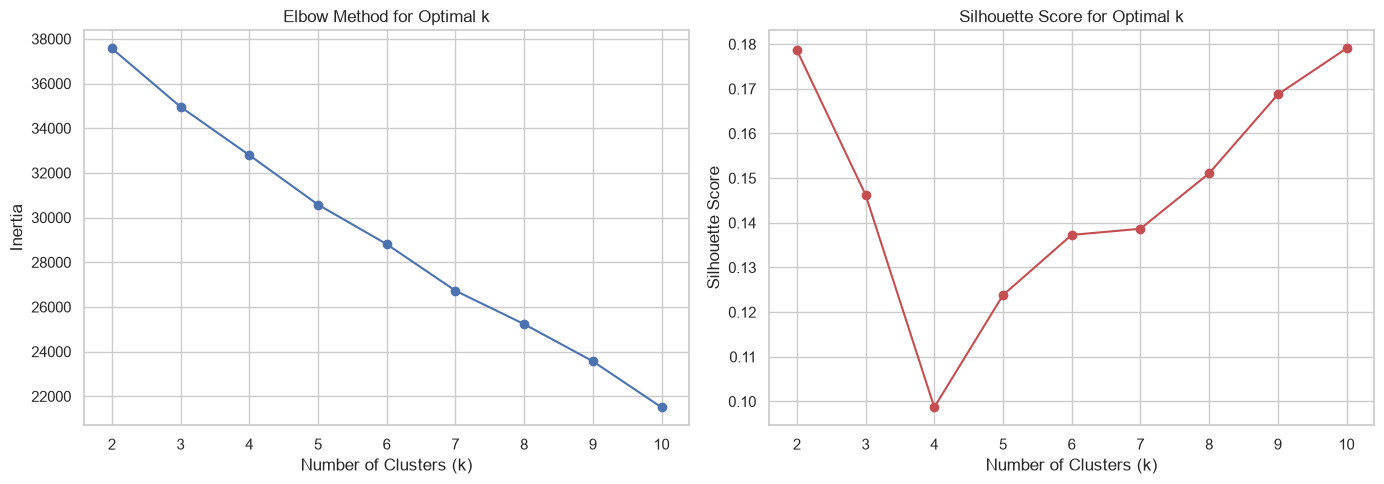

Silhouette scores for each k:
  k=2: 0.1787
  k=3: 0.1463
  k=4: 0.0987
  k=5: 0.1238
  k=6: 0.1373
  k=7: 0.1387
  k=8: 0.1511
  k=9: 0.1687
  k=10: 0.1790


In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different k values
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, kmeans.labels_))

# Plot Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia plot
axes[0].plot(k_range, inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method for Optimal k")
axes[0].grid(True)

# Silhouette score plot
axes[1].plot(k_range, silhouette_scores, "ro-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score for Optimal k")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Print silhouette scores
print("Silhouette scores for each k:")
for k, score in zip(k_range, silhouette_scores):
    print(f"  k={k}: {score:.4f}")

In [77]:
# Based on elbow and silhouette, choose k
k_chosen = 7  # Since there are 7 true classes, let's try k=7

kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

print(f"Chosen number of clusters: {k_chosen}")
print(f"Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Chosen number of clusters: 7
Cluster sizes:
0    371
1    735
2     44
3    394
4    506
5      7
6     54
Name: count, dtype: int64


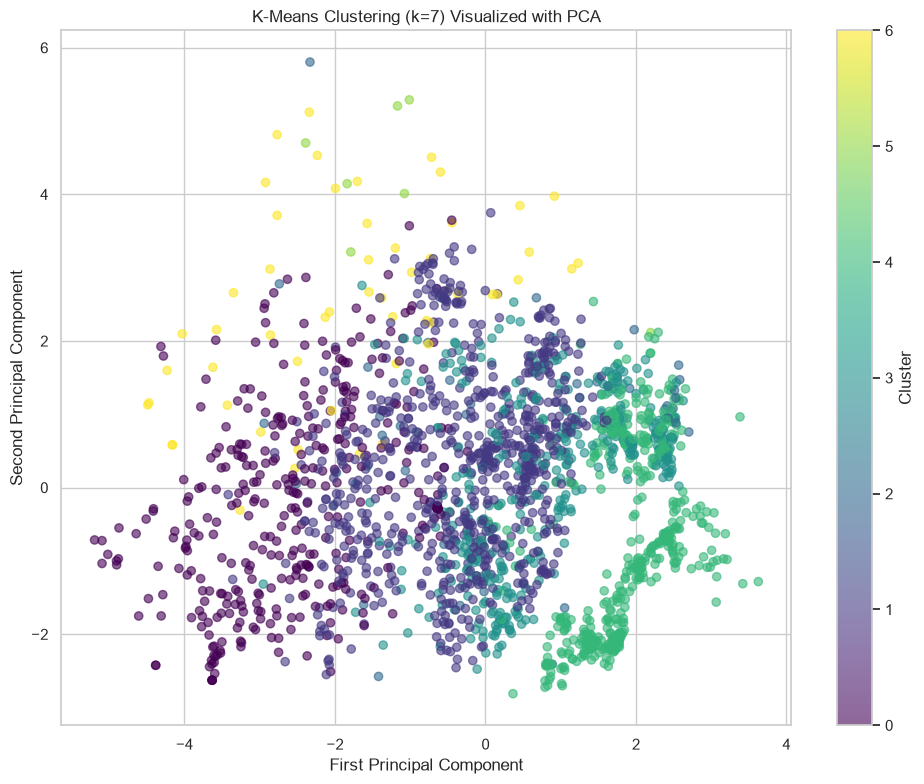

Explained variance ratio: [0.15596504 0.10039711]


In [78]:
from sklearn.decomposition import PCA

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.6
)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title(f"K-Means Clustering (k={k_chosen}) Visualized with PCA")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")


Crosstab of Cluster Labels vs True Obesity Classes:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,145,131,4,1,0,77,13
1,115,88,183,47,0,136,166
2,1,13,6,15,1,3,5
3,5,20,110,103,1,61,94
4,0,0,46,129,322,3,6
5,0,4,0,1,0,2,0
6,6,31,2,1,0,8,6


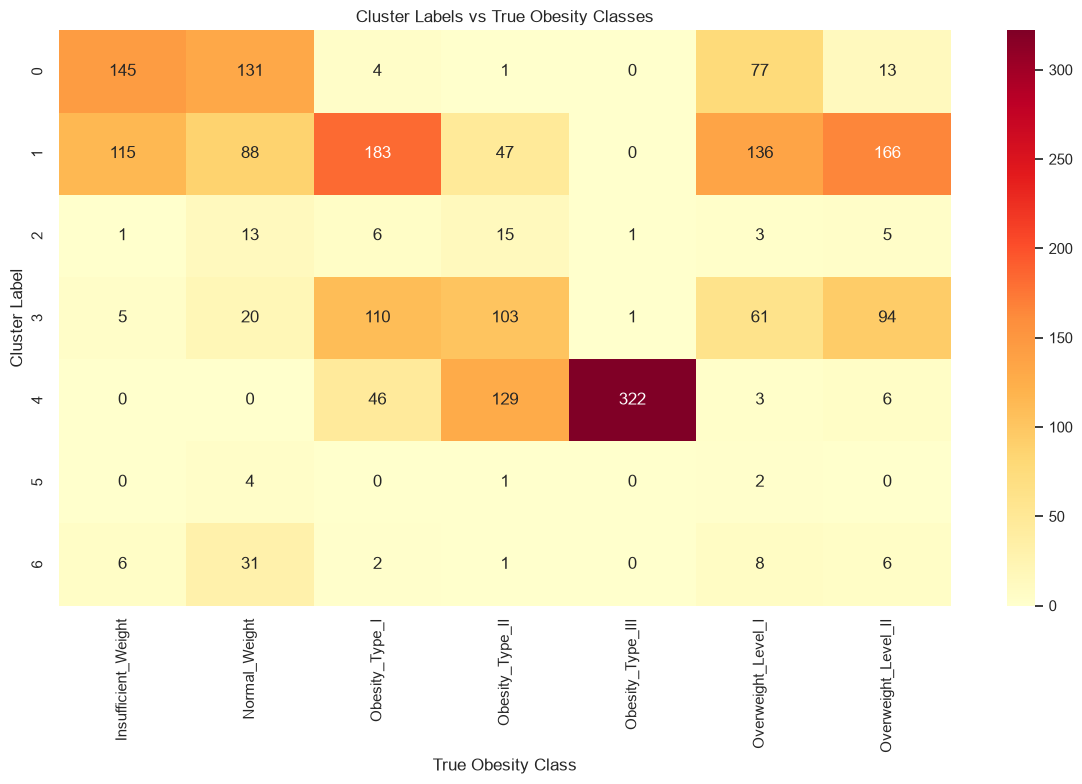


Cluster composition (as percentages):

Cluster 0 (Total: 371):
  Insufficient_Weight: 145 (39.1%)
  Normal_Weight: 131 (35.3%)
  Obesity_Type_I: 4 (1.1%)
  Obesity_Type_II: 1 (0.3%)
  Overweight_Level_I: 77 (20.8%)
  Overweight_Level_II: 13 (3.5%)

Cluster 1 (Total: 735):
  Insufficient_Weight: 115 (15.6%)
  Normal_Weight: 88 (12.0%)
  Obesity_Type_I: 183 (24.9%)
  Obesity_Type_II: 47 (6.4%)
  Overweight_Level_I: 136 (18.5%)
  Overweight_Level_II: 166 (22.6%)

Cluster 2 (Total: 44):
  Insufficient_Weight: 1 (2.3%)
  Normal_Weight: 13 (29.5%)
  Obesity_Type_I: 6 (13.6%)
  Obesity_Type_II: 15 (34.1%)
  Obesity_Type_III: 1 (2.3%)
  Overweight_Level_I: 3 (6.8%)
  Overweight_Level_II: 5 (11.4%)

Cluster 3 (Total: 394):
  Insufficient_Weight: 5 (1.3%)
  Normal_Weight: 20 (5.1%)
  Obesity_Type_I: 110 (27.9%)
  Obesity_Type_II: 103 (26.1%)
  Obesity_Type_III: 1 (0.3%)
  Overweight_Level_I: 61 (15.5%)
  Overweight_Level_II: 94 (23.9%)

Cluster 4 (Total: 506):
  Obesity_Type_I: 46 (9.1%)
  Obes

In [79]:
# Crosstab of clusters vs true labels
cluster_vs_true = pd.crosstab(cluster_labels, obesity["NObeyesdad"])
print("\nCrosstab of Cluster Labels vs True Obesity Classes:")
display(cluster_vs_true)

# Heatmap visualization
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_vs_true, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Cluster Labels vs True Obesity Classes")
plt.xlabel("True Obesity Class")
plt.ylabel("Cluster Label")
plt.tight_layout()
plt.show()

# Analyze cluster composition
print("\nCluster composition (as percentages):")
for cluster in range(k_chosen):
    total = cluster_vs_true.loc[cluster].sum()
    print(f"\nCluster {cluster} (Total: {total}):")
    for class_name, count in cluster_vs_true.loc[cluster].items():
        if count > 0:
            percentage = (count / total) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")

**Answer:** 

1. **How I chose k**:
   - I chose k=7 because there are 7 true obesity classes, and I wanted to see if K-Means would discover the same groups.
   - The elbow method showed the curve flattening around k=5-7, with no dramatic drop in inertia after k=5.
   - Silhouette scores tell an interesting story:
     - k=2 had the highest silhouette (0.1787) but 2 clusters would be too simplistic
     - k=4 had the lowest silhouette (0.0987), suggesting 4 clusters don't fit well
     - k=10 had the highest silhouette (0.1790), but more clusters may overcomplicate
     - The silhouette scores are all relatively low (0.10-0.18), indicating the clusters aren't perfectly separated and there's natural overlap between groups
   - I selected k=7 as it matches the true number of classes and gives interpretable results.

2. **Do clusters resemble true obesity levels?**:
   - **Strong agreement**:
     - Cluster 4 strongly captures Obesity_Type_III (63.6%) - severe obesity clusters together
     - Cluster 0 captures Insufficient_Weight (39.1%) and Normal_Weight (35.3%) - underweight/normal weight people group together
     - Cluster 3 captures Obesity_Type_I (27.9%) and Overweight_Level_II (23.9%) - moderate obesity levels
   
   - **Breakdowns/confusion**:
     - Cluster 1 is very mixed with all classes represented (15.6% to 24.9%) - it's capturing an "in-between" group
     - Cluster 2 and 6 are very small (44 and 54 samples) suggesting they might be outliers or specific subgroups
     - There's significant overlap between adjacent classes (Normal_Weight ↔ Overweight_Level_I ↔ Overweight_Level_II)
     - The clusters don't perfectly map to a single class each - there's natural overlap in feature space

   - **Why this makes sense**: 
     - Obesity is a continuous spectrum, not discrete categories
     - People near class boundaries naturally share characteristics
     - K-Means finds patterns based on feature similarity, not labels
     - The algorithm successfully separates severe obesity (Cluster 4) from underweight (Cluster 0) but struggles with middle categories

3. **Practical value in public health**:
   These clusters would be extremely valuable in a real public-health setting because:
   - **Screening tool**: Without needing expensive clinical assessments, we could quickly group individuals into risk categories based on simple measurements
   - **Targeted interventions**: Each cluster represents a different health profile with potentially different intervention needs:
     - Cluster 0 (underweight/normal): Focus on maintaining healthy weight
     - Cluster 4 (severe obesity): Most urgent intervention needed
     - Cluster 1 (mixed middle group): Diverse population requiring personalized approaches
   - **Resource allocation**: Health resources could be directed to clusters with the most severe health risks
   - **Monitoring trends**: Track how populations shift between clusters over time (e.g., after public health campaigns)
   - **Personalized recommendations**: Different clusters might respond differently to diet/exercise programs
   - **Early identification**: Identify individuals at risk of moving from Cluster 0/1 into more severe obesity clusters

The relatively low silhouette scores (0.10-0.18) actually reflect reality - obesity is a continuous spectrum with natural overlap between categories, making perfect separation impossible.

Section 4 — Reflection

**Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?**

The supervised Random Forest classifier learned specific boundaries between the 7 obesity classes, achieving 98.82% accuracy by identifying exactly which combination of features corresponds to each class. It learned that BMI is the dominant feature (37.6% importance), followed by Weight (19.9%), and used these to create precise decision boundaries.

K-Means, in contrast, discovered natural groupings without using any labels. It revealed that obesity is truly a continuous spectrum - while it separated severe obesity (Cluster 4 - 63.6% Obesity_Type_III) from underweight (Cluster 0 - 39.1% Insufficient_Weight), it struggled with middle categories where natural overlap exists. The low silhouette scores (0.10-0.18) confirm this overlap is real, not an algorithm limitation.

Key differences:
- Classifier learned **discrete boundaries** between categories
- Clustering revealed **continuous nature** of obesity
- Classifier could predict exact categories; clustering shows natural groupings
- Classifier is more practical for diagnosis; clustering better for discovering hidden patterns

**Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?**

Regression (tips) evaluation was fundamentally different:
- Used RMSE to measure prediction error magnitude ($4.80-$5.04)
- Used R² to measure variance explained (only 3.7-5.1% - very poor!)
- The low R² revealed that tips are hard to predict from trip characteristics alone
- Scatter plots showed prediction quality visually
- Errors are measured in dollars - we care about how much we're off

Classification (obesity) evaluation was much more successful:
- Used Accuracy (98.82%) and Macro-F1 (98.77%) - excellent performance!
- Confusion matrix showed which classes were confused
- Classification report gave per-class precision/recall
- The high performance suggests the features are highly predictive of obesity
- Errors are measured in misclassifications - we care about which class was chosen

Key insight: Regression (tips) was hard because tip behavior is influenced by many unmeasured factors (service quality, weather, passenger mood). Classification (obesity) was easier because the features (BMI, weight, eating habits) are directly related to the target.

**Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?**

The biggest train-vs-test gap occurred in the **classification task with Random Forest**, which had perfect training accuracy (100%) but test accuracy (98.82%) - a 1.18% gap. While this gap is small, it still indicates some overfitting.

The single most effective thing to close this gap would be **hyperparameter tuning with cross-validation**:

Specifically, I would:
1. **Reduce max_depth** from 10 to 6-7 to limit tree complexity
2. **Increase min_samples_split** from 2 to 10-15 to prevent over-splitting
3. **Increase min_samples_leaf** from 1 to 5-8 to ensure enough samples per leaf
4. Use **GridSearchCV** with 5-fold cross-validation on the training data to find optimal parameters
5. Consider **pruning** the decision trees or using **early stopping**

For the regression task (tips), the gap was small (R²: 0.0515 train vs 0.0512 test) but overall performance was poor. Here I would focus on **feature engineering** and adding more relevant features (time of day, weather, day of week) rather than addressing overfitting.

For the clustering task, overfitting isn't relevant since it's unsupervised - the clusters represent natural groupings.